# Air Traffic Data Analysis - Student Exercise

## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:

- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)


## 1. Setup and Data Loading


In [ ]:
# Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, scipy.stats, and sklearn modules
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set up plotting style (optional)
plt.style.use("default")
sns.set_palette("husl")

In [2]:
# Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

try:
    # Your code to load the dataset:
    df = pd.read_csv("air_traffic_data.csv")
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(
        0, 10000, n_samples
    )
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(
        0, 15000, n_samples
    )

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame(
        {
            "Dom_Flt": dom_flights.astype(int),
            "Int_Flt": int_flights.astype(int),
            "Flt": (dom_flights + int_flights).astype(int),
            "Dom_Pax": dom_pax.astype(int),
            "Int_Pax": int_pax.astype(int),
            "Pax": (dom_pax + int_pax).astype(int),
            "Dom_RPM": dom_rpm.astype(int),
        }
    )

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


## 2. Exploratory Data Analysis


In [3]:
# Display basic information about the dataset
# Hint: Use df.info(), df.head(), and df.describe() to explore the data

print("Dataset Info:")
print(df.info())


print("\nFirst 5 rows:")
display(df.head())


print("\nBasic Statistics:")
df.describe(include="all")


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB
None

First 5 rows:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
0,16490,8715,25205,152866,176257,329123,124207802
1,14585,9121,23706,148316,136571,284888,112284645
2,16943,10166,27109,212190,156317,368508,172347465
3,19569,10107,29676,250224,127892,378116,213773981
4,14297,5244,19542,162835,82306,245142,131063749



Basic Statistics:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,14877.170000,8171.215000,23048.875000,175331.340000,126924.080000,302255.885000,1.406821e+08
std,2793.014056,1973.997049,3570.262195,44857.540799,39219.620597,59904.148005,4.199422e+07
min,7140.000000,1517.000000,13177.000000,81758.000000,36755.000000,163559.000000,6.330140e+07
25%,12883.750000,6787.750000,20647.000000,142793.750000,100451.000000,265141.250000,1.111673e+08
50%,14987.000000,8157.000000,23250.500000,171194.000000,125890.000000,297932.000000,1.348214e+08
75%,16502.250000,9374.000000,25237.250000,199115.000000,154947.000000,339630.250000,1.634872e+08
max,23160.000000,15705.000000,32333.000000,337112.000000,244469.000000,526087.000000,3.312472e+08


In [4]:
# Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())

print("Missing values:")
df.isnull().sum()


# Handle missing values if any (uncomment and complete if needed)
# if df.isnull().sum().sum() > 0:
#     print("\nHandling missing values...")
#     df = # TODO: Complete this line (use dropna() or fillna())
#     print(f"New shape after handling missing values: {df.shape}")

Missing values:


,0
Dom_Flt,0
Int_Flt,0
Flt,0
Dom_Pax,0
Int_Pax,0
Pax,0
Dom_RPM,0


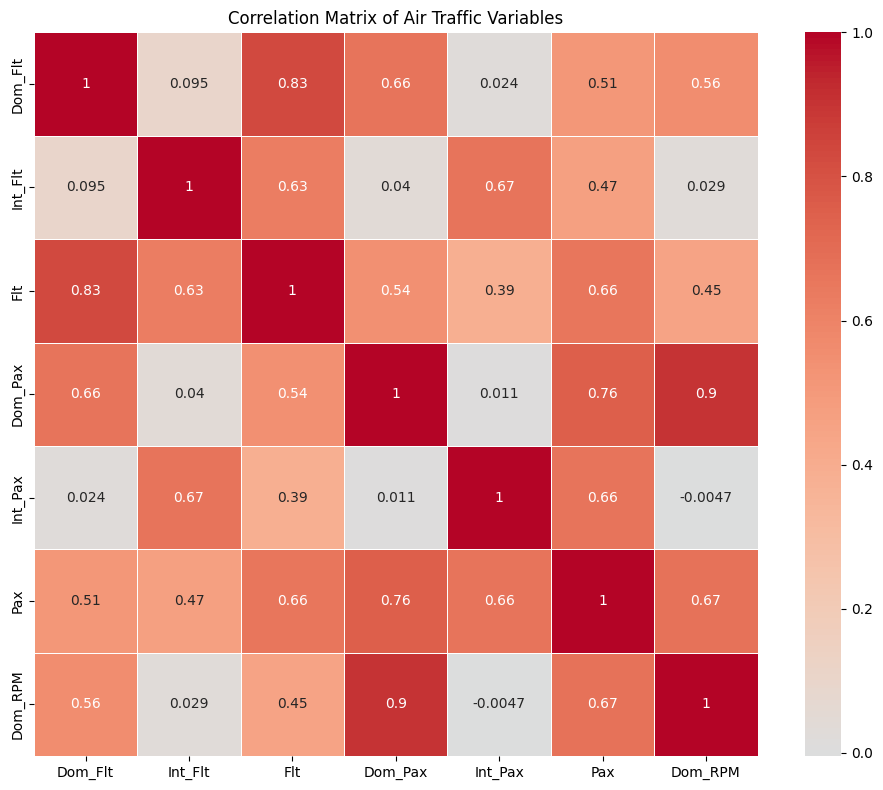

Strongest correlations:
Dom_Pax, Dom_RPM: 0.902
Dom_Flt, Flt: 0.835
Dom_Pax, Pax: 0.756


In [5]:
# Create and analyze correlation matrix
# Hint: Use df.corr() to calculate correlations and sns.heatmap() to visualize

plt.figure(figsize=(10, 8))
# Calculate correlation matrix:
correlation_matrix = df.corr()

# Create heatmap:
# Use sns.heatmap() with parameters: annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5
sns.heatmap(
    data=correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)

plt.title("Correlation Matrix of Air Traffic Variables")
plt.tight_layout()
plt.show()

# Find and print the strongest correlations
# Hint: Look at the correlation matrix values (excluding diagonal)
# Get only the upper triangle to avoid duplicate pairs and the diagonal.

threshold = 0.7
corr_pairs = (
    correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .sort_values(key=abs, ascending=False)
)
strong_pairs = corr_pairs[corr_pairs.abs() > threshold]

print("Strongest correlations:")
for (var1, var2), value in strong_pairs.items():
    print(f"{var1}, {var2}: {value:.3f}")

## 3. Hypothesis Testing


In [6]:
# Hypothesis Test 1 - Compare domestic and international passengers
# Hint: Use stats.ttest_ind() to perform independent t-test

print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
t_stat, p_value = stats.ttest_ind(df["Dom_Pax"], df["Int_Pax"])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Print the mean values for both groups
print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():,.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():,.0f}")

# Interpret the results
# Hint: Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # The conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(
        f"Domestic flight carry "
        f"{(df['Dom_Pax'].mean() / df['Int_Pax'].mean() - 1) * 100:.1f}"
        f"% more passengers on average "
        f"({df['Dom_Pax'].mean():,.0f} vs {df['Int_Pax'].mean():,.0f}), and with p-value of {p_value:.6f}, this is very unlikely to be due to chance."
    )
else:
    # The conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print(
        "No statistically significant difference was found between domestic and international passenger volumes."
    )

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 11.4892
P-value: 0.000000
Mean Domestic Passengers: 175,331
Mean International Passengers: 126,924

Conclusion: Reject H0 (p < 0.05)
Domestic flight carry 38.1% more passengers on average (175,331 vs 126,924), and with p-value of 0.000000, this is very unlikely to be due to chance.


In [7]:
# Hypothesis Test 2 - Test correlation between total passengers and total flights
# Hint: Use stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
correlation_coef, p_value_corr = stats.pearsonr(df["Pax"], df["Flt"])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# Interpret the correlation test results
# Hint: Compare p_value_corr with alpha and interpret the correlation coefficient
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(
        f"There is a significant correlation between total passengers and total flights."
    )
    # Add interpretation about positive/negative correlation
    if correlation_coef > 0:
        print(
            "What does positive correlation mean?\n"
            "A positive correlation mean that the two variables (Total passengers, Total flights) move in the same direction, so when one variable increases, the other variable also increases.\n"
            "In other words, more flights <--> more passengers."
        )
    else:
        print(
            "What does negative correlation mean?\n"
            "A negative correlation means that the two variables move in opposite directions, so when one variable increases, the other variable decreases.\n"
            "In other words, more flights --> less passengers (and vice versa)."
        )
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print(
        "No statistically significant difference was found between total flights and total passengers."
    )


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.6592
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
What does positive correlation mean?
A positive correlation mean that the two variables (Total passengers, Total flights) move in the same direction, so when one variable increases, the other variable also increases.
In other words, more flights <--> more passengers.


## 4. Simple Linear Regression


In [8]:
# Build a simple linear regression model
# Goal: Predict Total Passengers from Total Flights
# Hint: Use sklearn's LinearRegression class

print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
X_simple = df[["Flt"]]  # Select the feature column (Total Flights)
y_simple = df["Pax"]  # Select the target column (Total Passengers)

# Split the data:
# Use train_test_split with test_size=0.2, random_state=42
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

# Create and train the model:
simple_model = LinearRegression()
# Fit the model using X_train_simple and y_train_simple
simple_model.fit(X_train_simple, y_train_simple)


# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple)

# Calculate performance metrics
# Hint: Use r2_score, mean_squared_error, mean_absolute_error
r2_simple = r2_score(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
rmse_simple = root_mean_squared_error(y_test_simple, y_pred_simple)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# Print the model equation
# Hint: Use simple_model.intercept_ and simple_model.coef_[0]
print(
    f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Flights"
)

Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: 0.2977
Mean Squared Error: 2141846835.14
Root Mean Squared Error: 46280.09
Mean Absolute Error: 36607.08

Model Equation: Passengers = 37484.48 + 11.45 × Flights


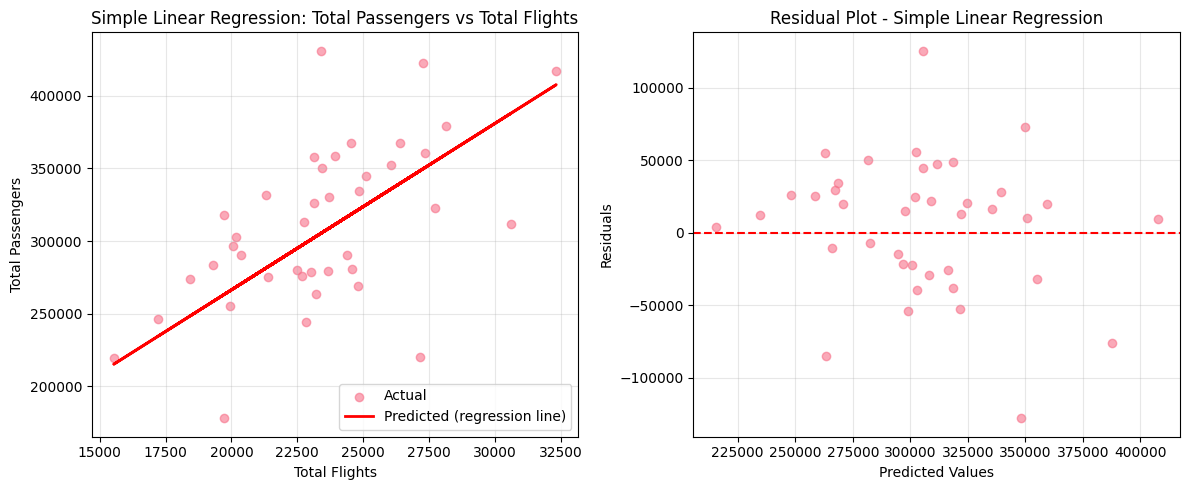

In [9]:
# Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

# Plot 1: Scatter plot with regression line
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Create scatter plot of actual vs predicted values
# Hint: Use plt.scatter() for actual and predicted points, and plt.plot() for the line
plt.scatter(X_test_simple, y_test_simple, alpha=0.6, label="Actual")
plt.plot(
    X_test_simple,
    y_pred_simple,
    color="red",
    linewidth=2,
    label="Predicted (regression line)",
)

plt.xlabel("Total Flights")
plt.ylabel("Total Passengers")
plt.title("Simple Linear Regression: Total Passengers vs Total Flights")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# Calculate residuals and create residual plot
# Hint: residuals = actual - predicted
residuals = y_test_simple - y_pred_simple

# Create scatter plot of predicted vs residuals
plt.scatter(y_pred_simple, residuals, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Simple Linear Regression")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression


In [10]:
# Build a multiple linear regression model
# Goal: Predict Total Passengers using multiple features
# Hint: Avoid using Pax in features since that's our target (multicollinearity)

print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# Select appropriate features
# Hint: Use columns like Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM (avoid Pax and Flt)
feature_columns = ["Dom_Flt", "Int_Flt", "Dom_RPM"]

X_multiple = df[feature_columns]
y_multiple = df["Pax"]

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# Split the data
# Hint: Use train_test_split with test_size=0.2, random_state=42
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(
    X_multiple, y_multiple, test_size=0.2, random_state=42
)

# Apply feature scaling (recommended for multiple regression)
# Hint: Use StandardScaler
scaler = StandardScaler()
X_train_mult_scaled = scaler.fit_transform(X_train_mult)
X_test_mult_scaled = scaler.transform(X_test_mult)

# Create and train the multiple regression model
multiple_model = LinearRegression()
# Fit the model
multiple_model.fit(X_train_mult_scaled, y_train_mult)


# Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled)

# TODO: Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult)
mse_mult = mean_squared_error(y_test_mult, y_pred_mult)
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult)
rmse_mult = root_mean_squared_error(y_test_mult, y_pred_mult)

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Dom_Flt', 'Int_Flt', 'Dom_RPM']
Target: Total Passengers (Pax)

Model Performance:
R² Score: 0.4889
Mean Squared Error: 1558603819.06
Root Mean Squared Error: 39479.16
Mean Absolute Error: 31721.62

Feature Coefficients (after scaling):
Dom_Flt: 8210.0902
Int_Flt: 28294.9942
Dom_RPM: 36812.9443
Intercept: 300303.27


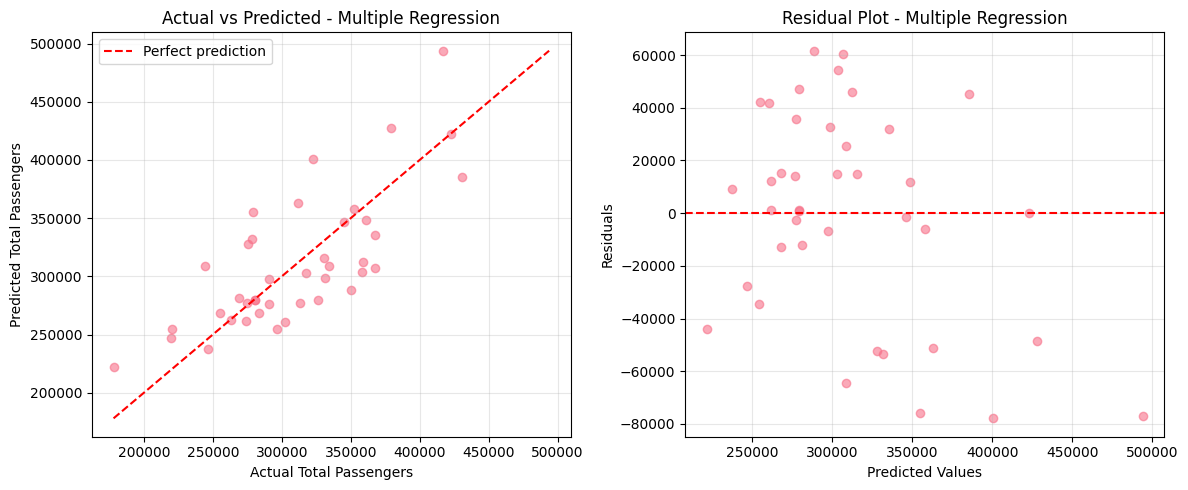

In [11]:
# Visualize multiple regression results
# Create actual vs predicted plot and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)

# Create scatter plot of actual vs predicted values
plt.scatter(y_test_mult, y_pred_mult, alpha=0.6)

lims = [
    min(y_test_mult.min(), y_pred_mult.min()),
    max(y_test_mult.max(), y_pred_mult.max()),
]

# Add a diagonal reference line (perfect prediction line)
plt.plot(
    lims,
    lims,
    color="red",
    linestyle="--",
    label="Perfect prediction",
)

plt.xlabel("Actual Total Passengers")
plt.ylabel("Predicted Total Passengers")
plt.title("Actual vs Predicted - Multiple Regression")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)

# Calculate residuals and create residual plot
residuals_mult = y_test_mult - y_pred_mult

# Create scatter plot of predicted vs residuals
plt.scatter(y_pred_mult, residuals_mult, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Multiple Regression")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis


In [12]:
# Compare the performance of both models
# Create a comparison table and determine which model performs better

print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)

# Print comparison of R², RMSE, and MAE
# Hint: Use the metrics calculated in previous sections
print(f"{'R² Score:':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'Root Mean Squared Error:':<25} {rmse_simple:<20.4f} {rmse_mult:<20.2f}")
print(f"{'Mean Absolute Error:':<25} {mae_simple:<20.4f} {mae_mult:<20.2f}")


print("=" * 50)

# Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = (r2_mult - r2_simple) / r2_simple * 100
else:
    better_model = "Simple Regression"
    improvement = (r2_simple - r2_mult) / r2_mult * 100

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R² Score:                 0.2977               0.4889              
Root Mean Squared Error:  46280.0911           39479.16            
Mean Absolute Error:      36607.0841           31721.62            

Best Model: Multiple Regression
R² Improvement: 64.24%


## 7. Statistical Insights and Conclusions


In [13]:
# Summarize your findings and provide insights
# Include results from hypothesis tests, regression analysis, and key findings

print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
# Summarize your hypothesis test results
print(
    f"   • Domestic vs International Passengers: Domestic flight carry "
    f"{(df['Dom_Pax'].mean() / df['Int_Pax'].mean() - 1) * 100:.1f}"
    f"% more passengers on average "
    f"({df['Dom_Pax'].mean():,.0f} vs {df['Int_Pax'].mean():,.0f}), and with p-value of {p_value:.6f}, this is very unlikely to be due to chance."
)
print(
    f"   • Correlation between Total Passengers and Flights: There is a significant correlation between total passengers and total flights. More flights <--> more passengers."
)

print("\n2. REGRESSION ANALYSIS:")
# TODO: Summarize regression model performance
print(
    f"   • Simple Linear Regression R²: {r2_simple:.4f} - Flights alone explain only ~30% of the variance in passenger totals (RMSE {rmse_simple:,.0f}, about 15% of mean Pax)."
)
print(
    f"   • Multiple Linear Regression R²: {r2_mult:.4f} - Using Dom_Flt, Int_Flt, and Dom_RPM together explains ~49% of variance (RMSE {rmse_mult:,.0f}), after removing Dom_Pax / Int_Pax, which had caused false 100% accuracy through target leakage."
)
print(
    f"   • Best performing model: {better_model}, a {improvement:.2f}% relative R² improvement over the simple model, with lower RMSE and MAE on every metric."
)

print("\n3. KEY FINDINGS:")
# TODO: Identify and discuss key findings from your analysis
print(
    f"   • Pax is exactly Dom_Pax + Int_Pax by construction. Including both as regression features will produce a fraudulent R² of 1, which is a good reminder to check for definitional relationships between columns before trusting a model's performance, not just avoid the literal target column."
)
print(
    f"   • Among legitimate predictors, Dom_RPM carries the strongest signal (coefficient {multiple_model.coef_[feature_columns.index('Dom_RPM')]:.2f} after scaling), but it is self correlated 0.902 with Dom_Pax, so its dominance partly reflects that underlying relationship rather than an independent operational signal."
)
print(
    f"   • Both regression models under-predict high-volume routes and over-predict low-volume ones (visible in the Actual vs Predicted plot). That is consistent with domestic flights carrying 38.1% more passengers on average than international ones, a factor flight / RPM counts alone don't fully capture."
)

print("\n4. RECOMMENDATIONS:")
# TODO: Provide practical recommendations based on your analysis
print(
    "   • Before feature selection, explicitly check the correlation matrix for near 1 or exactly derived relationships, not just exclude the target column by name."
)
print(
    "   • Since Dom_RPM overlaps heavily with Dom_Pax, a production model should source an independent operational metric (e.g load factor or seat capacity) rather than one this correlated with a passenger count."
)
print(
    "   • Given the domestic / international volume gap and weaker model performance at the extremes, consider separate regression models per route type instead of one pooled model across both."
)

STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: Domestic flight carry 38.1% more passengers on average (175,331 vs 126,924), and with p-value of 0.000000, this is very unlikely to be due to chance.
   • Correlation between Total Passengers and Flights: There is a significant correlation between total passengers and total flights. More flights <--> more passengers.

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: 0.2977 - Flights alone explain only ~30% of the variance in passenger totals (RMSE 46,280, about 15% of mean Pax).
   • Multiple Linear Regression R²: 0.4889 - Using Dom_Flt, Int_Flt, and Dom_RPM together explains ~49% of variance (RMSE 39,479), after removing Dom_Pax / Int_Pax, which had caused false 100% accuracy through target leakage.
   • Best performing model: Multiple Regression, a 64.24% relative R² improvement over the simple model, with lower RMSE and MAE on every metric.

3. KEY FINDINGS:
   • 

## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

    The test results were expected, because domestic flights are usually cheaper than international ones, so more people can afford them (even though the domestic planes are most likely smaller than international ones). On top of that, it was quite expected that more flights equated to more passengers (and vice versa).

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

    The multiple regression model performed better (~64% R² improvement and lower RMSE and MAE too). The simple model only sees `Flt` (`Dom_Flt` + `Int_Flt`), but domestic and international flights don't necessarily carry passengers at the same rate. By giving the multiple regression model `Dom_Flt` and `Int_Flt` as separate features, each gets its own coefficient, so the model can finally account for that per-flight-type difference instead of averaging it away. In other words, the multiple regression model can 'see' distinctions that the simple model can't.
    Also, the `Dom_RPM` adds a new signal that the flight counts don't carry. So the multiple regression model gets a strong hint about the actual passenger scale, something `Flt` alone can't provide.
    The R² measures how much of the spread in total passengers numbers the model can account for using the features we gave it. 0.4889 R² means that if we look at all the ways `Pax` varies across the dataset's rows, the `Dom_flt / Int_Flt / Dom_RPM` model explains about 49% of that variation. The remaining 51% come from things the model simply doesn't know about. It is a measure of how much of the variability the model captures versus leaves as unexplained noise.

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

    The strongest correlations we found were `Dom_Pax <-> Dom_RPM: 0.902`, `Dom_Flt <-> Flt: 0.835`, and `Dom_Pax <-> Pax: 0.756`. However, these correlations don't tell us something we didn't know already. E.g `Dom_Flt <-> Flt` (0.835), but given that domestic flights make up a bigger share of the total flights (mean 14,877 vs 8,171), `Dom_Flt` will correlate strongly with `Flt` _no matter what_.
    Contrast that with `Pax <-> Flt: 0.659` which are not tied to each other in the same direct way. `Pax` counts people and `Flt` counts flights, and nothing forces them to move together except the fact that scheduling more flights tends to carry more people. That correlation is one that reflects actual airline behaviors. Given the data we have available in the dataset, if a scheduling team is planning flights for new routes or seasons, this gives them a passenger estimate straight from the flight count they're planning, which could be useful for staffing, gate and catering estimates before any demand signals arrive. Of course, this is only a starting point, and not a final number since individual predictions can be off by tens of thousands of passengers (RMSE ~ 46,280).

4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

    Since neither model's residuals showed a strong curve or funnel shape, a straight-line model wasn't the wrong choice. Both models show the same failure pattern: under-predicting high-passenger-volume points, and over-predicting low-volume ones.

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

    We found that domestic flights carry 38.1% more passengers on average, and with `t=11.49` and `p ~ 0`, that's a statistically defensible basis for decisions like staffing ratios, gate allocations, or check-in counter distributions between domestic and international terminals. Because the test showed the gap is real, an airline could justify weighting resources toward domestic operations rather than splitting evenly.
